In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [5]:
f = pd.read_csv('titanic.csv')
df = pd.DataFrame(f)
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Survived                 887 non-null    int64  
 1   Pclass                   887 non-null    int64  
 2   Name                     887 non-null    str    
 3   Sex                      887 non-null    str    
 4   Age                      887 non-null    float64
 5   Siblings/Spouses Aboard  887 non-null    int64  
 6   Parents/Children Aboard  887 non-null    int64  
 7   Fare                     887 non-null    float64
dtypes: float64(2), int64(4), str(2)
memory usage: 55.6 KB
None


<>:28: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:28: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
C:\Users\abhij\AppData\Local\Temp\ipykernel_22128\1627322893.py:28: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


Data Shape: (887, 8)

Data Types: 
 Survived                     int64
Pclass                       int64
Name                           str
Sex                            str
Age                        float64
Siblings/Spouses Aboard      int64
Parents/Children Aboard      int64
Fare                       float64
dtype: object

Missing Values: 
 Survived                   0
Pclass                     0
Name                       0
Sex                        0
Age                        0
Siblings/Spouses Aboard    0
Parents/Children Aboard    0
Fare                       0
dtype: int64

Summary Stats:
           Survived      Pclass                    Name   Sex         Age  \
count   887.000000  887.000000                     887   887  887.000000   
unique         NaN         NaN                     887     2         NaN   
top            NaN         NaN  Mr. Owen Harris Braund  male         NaN   
freq           NaN         NaN                       1   573         NaN   
mean     

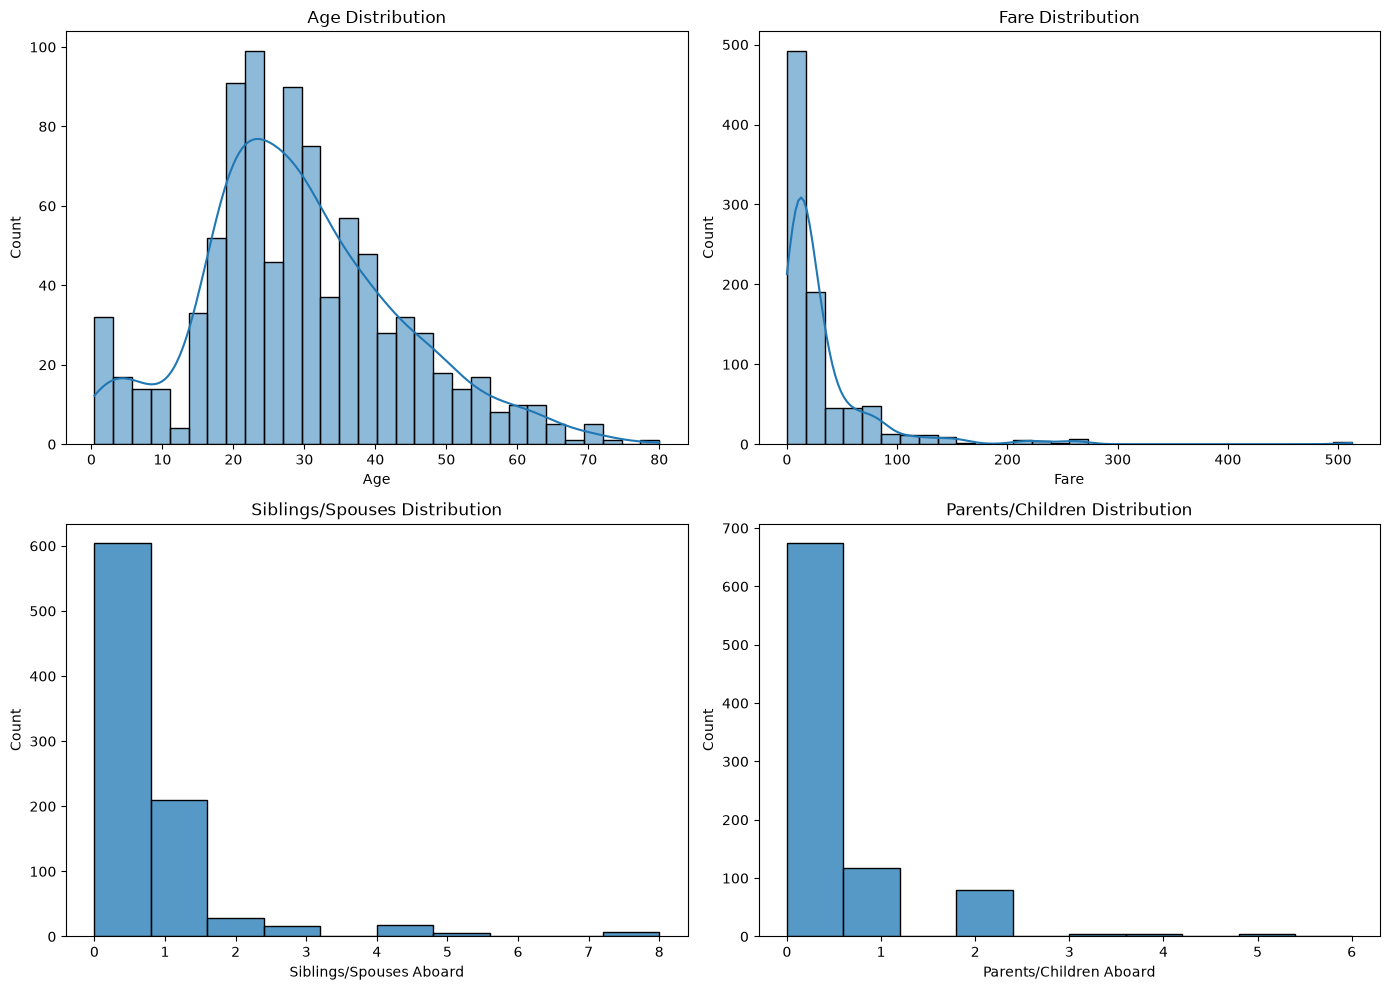

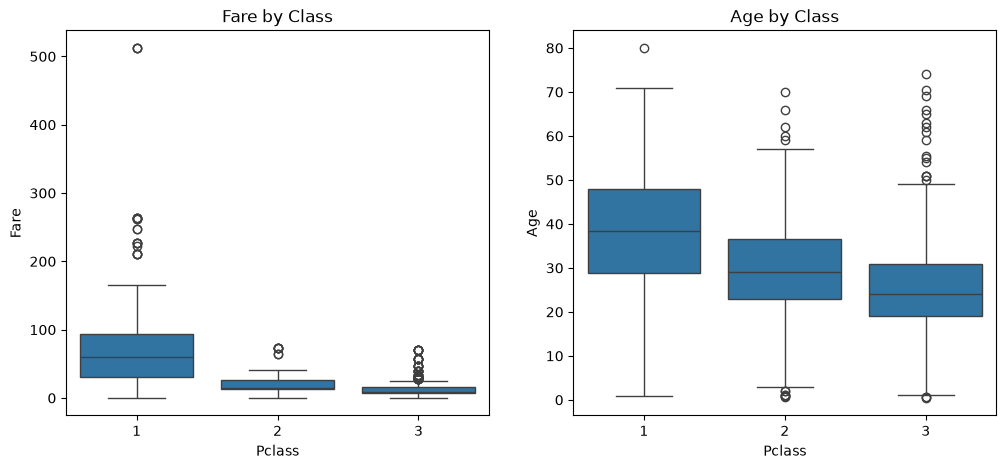

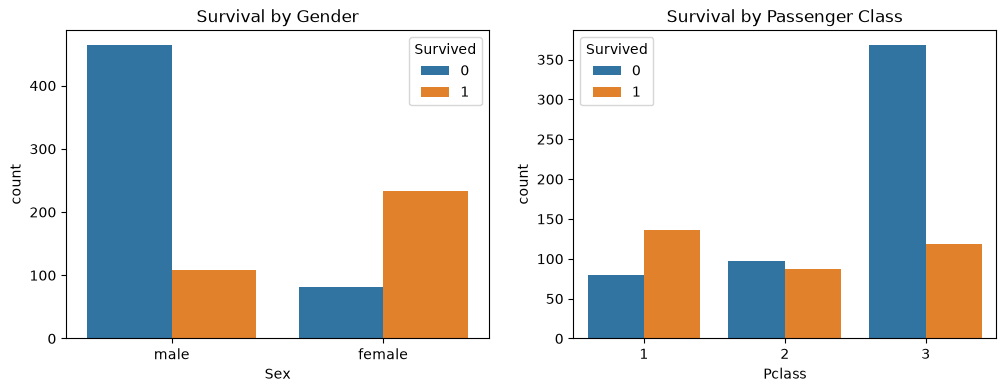

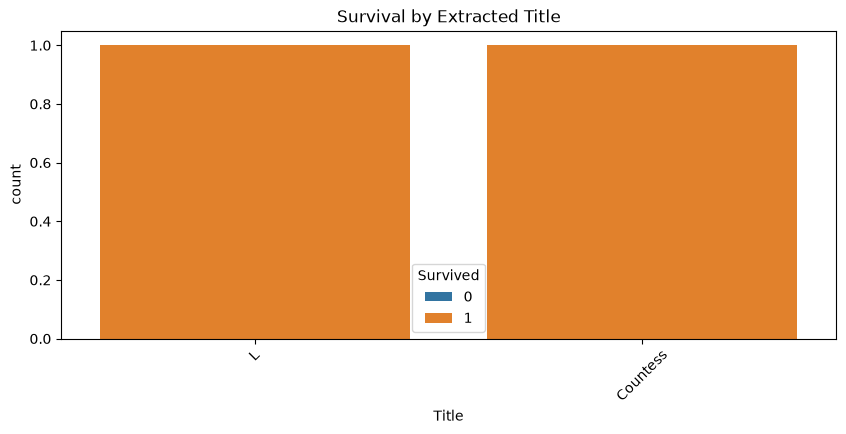

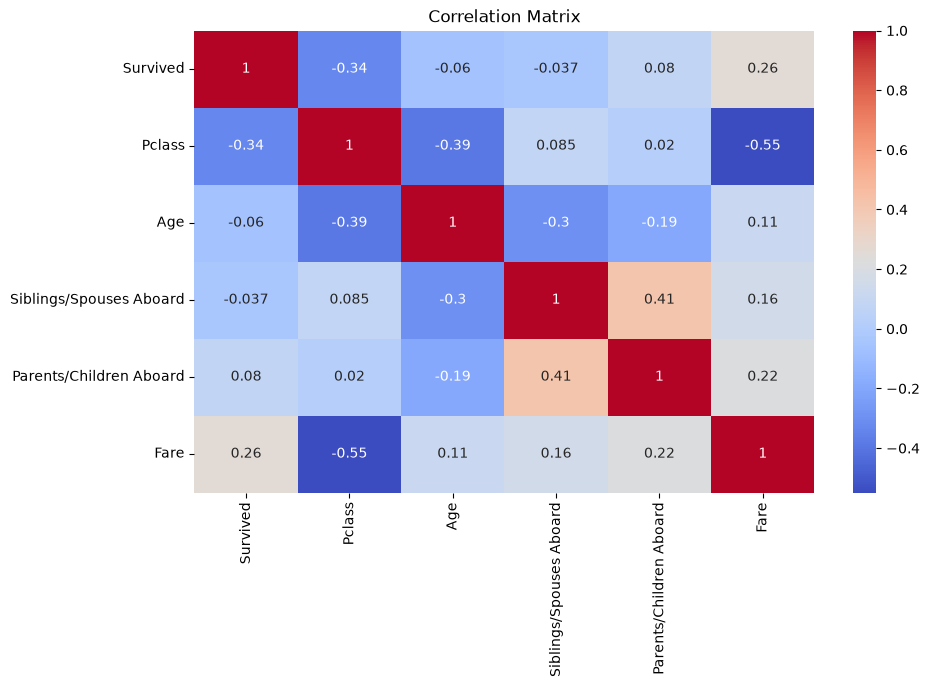

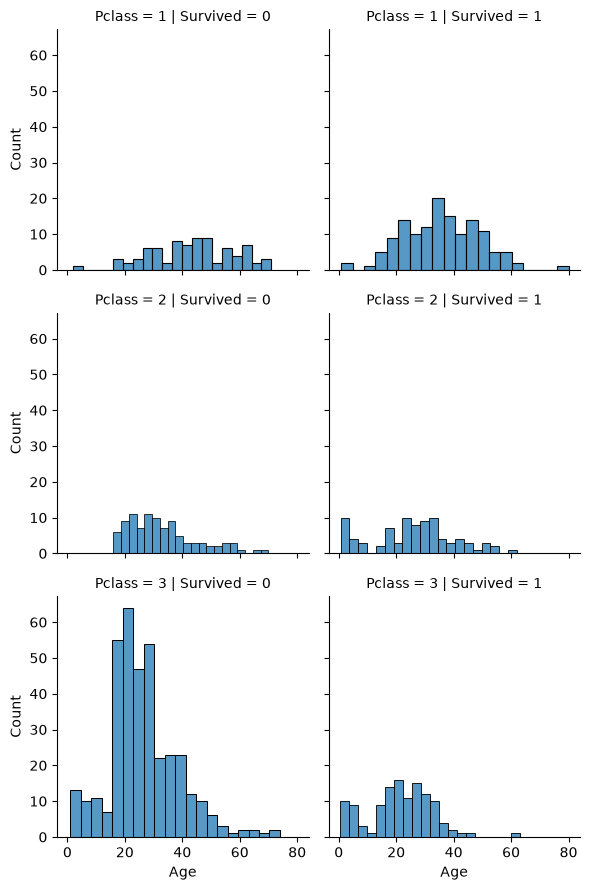

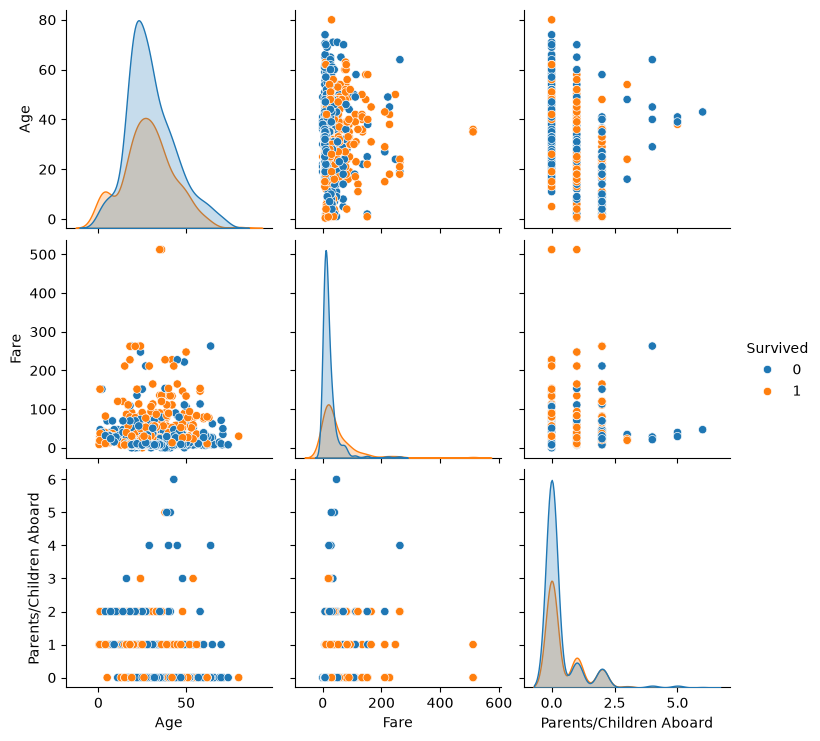

In [6]:
print("Data Shape:", df.shape)
print("\nData Types: \n", df.dtypes)
print("\nMissing Values: \n", df.isnull().sum())

# 2. Summary Statistics
print("\nSummary Stats:\n", df.describe(include='all'))

# 3. Distribution Analysis (Numerical & Categorical)
# Numerical Features: Age, Siblings/Spouses Aboard, Parents/Children Aboard, Fare
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df['Age'], bins=30, kde=True, ax=ax[0, 0]).set_title('Age Distribution')
sns.histplot(df['Fare'], bins=30, kde=True, ax=ax[0, 1]).set_title('Fare Distribution')
sns.histplot(df['Siblings/Spouses Aboard'], bins=10, kde=False, ax=ax[1, 0]).set_title('Siblings/Spouses Distribution')
sns.histplot(df['Parents/Children Aboard'], bins=10, kde=False, ax=ax[1, 1]).set_title('Parents/Children Distribution')
plt.tight_layout()

# Boxplots for numerical vs categorical (Pclass)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x='Pclass', y='Fare', data=df, ax=ax[0]).set_title('Fare by Class')
sns.boxplot(x='Pclass', y='Age', data=df, ax=ax[1]).set_title('Age by Class')

# Categorical Features: Survived, Pclass, Sex
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='Sex', hue='Survived', data=df, ax=ax[0]).set_title('Survival by Gender')
sns.countplot(x='Pclass', hue='Survived', data=df, ax=ax[1]).set_title('Survival by Passenger Class')

# Text Feature: Name (Feature Engineering - Title Extraction)
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
plt.figure(figsize=(10, 4))
sns.countplot(x='Title', hue='Survived', data=df).set_title('Survival by Extracted Title')
plt.xticks(rotation=45)

# 4. Correlation & Relationships
plt.figure(figsize=(10, 6))
# Using numeric_only=True to avoid errors with 'Name', 'Sex', and 'Title'
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')

# Cross-Tabulation
print("\nSurvival Rate by Pclass (%):")
print(pd.crosstab(df['Pclass'], df['Survived'], normalize='index') * 100)

print("\nSurvival Rate by Sex (%):")
print(pd.crosstab(df['Sex'], df['Survived'], normalize='index') * 100)

# 5. Outlier Detection
# Z-Score Analysis on Fare
z_scores_fare = np.abs(stats.zscore(df['Fare']))
outliers_fare = df[z_scores_fare > 3]
print(f"\nFound {len(outliers_fare)} Fare outliers (Z-score > 3)")

# Z-Score Analysis on Siblings/Spouses Aboard
z_scores_sibsp = np.abs(stats.zscore(df['Siblings/Spouses Aboard']))
outliers_sibsp = df[z_scores_sibsp > 3]
print(f"Found {len(outliers_sibsp)} Siblings/Spouses outliers (Z-score > 3)")

# 6. Advanced Visualizations
# Faceted Analysis
g = sns.FacetGrid(df, col='Survived', row='Pclass', height=3)
g.map(sns.histplot, 'Age', bins=20)

# Pairplot for Multivariate Analysis
sns.pairplot(df[['Age', 'Fare', 'Parents/Children Aboard', 'Survived']], hue='Survived')
plt.show()